# Phase 1 — Conditional WGAN-GP for Earthquake Spectral Acceleration (SA)

This notebook trains a **Conditional Wasserstein GAN with Gradient Penalty** to learn
the mapping from physical metadata (*Mw, Rrup, Ztor, Vs30*) and spectral period (*T*)
to **log Spectral Acceleration (log SA)**.

A **physics-informed monotonic distance-attenuation** penalty is added to the Generator
loss so that predicted SA decreases with increasing rupture distance.

## 0 · Environment & Setup

In [2]:
import os, sys, warnings
warnings.filterwarnings("ignore")

# ---------- Colab vs. Local detection ----------
try:
    from google.colab import drive
    IN_COLAB = True
    drive.mount("/content/drive")
    WORK_DIR = "/content/drive/MyDrive/WGAN_IITM/"
except ModuleNotFoundError:
    IN_COLAB = False
    WORK_DIR = os.getcwd()  # assumed to be WGAN_IITM/

os.chdir(WORK_DIR)
print(f"Working directory → {os.getcwd()}")
print(f"Running on {'Google Colab' if IN_COLAB else 'local machine'}")

Mounted at /content/drive
Working directory → /content/drive/MyDrive/WGAN_IITM
Running on Google Colab


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# ---------- Device ----------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device → {device}")

# ---------- Reproducibility ----------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device → cuda


## 1 · Data Loading & Preprocessing

In [4]:
# ── 1a. Load the raw Excel file ──────────────────────────────────────────────
raw = pd.read_excel("nga_subduction.xlsx")
print(f"Raw shape: {raw.shape}")

# Row 0 in this file is a spurious sub-header row (all NaN for numeric fields).
# Drop it and reset the index.
raw = raw.drop(index=0).reset_index(drop=True)
print(f"After dropping header row: {raw.shape}")
raw.head()

Raw shape: (10240, 48)
After dropping header row: (10239, 48)


,RSN,EQID,Mw,Depth,ev_lat_long,Unnamed: 5,FM,Region,Region flag,Rhyp,...,9,10,Station name,Rhyp.1,Zhyp,st_lat_long,Unnamed: 44,YEAR,MODY,HRMN
0,1000002.0,1000001.0,7.96,103.7969,51.6928,178.8871,1.0,'Alaska',1.0,488.314795,...,0.000395,0.000390,'ATKA',488.314795,103.7969,52.2016,-174.1975,2014.0,623.0,2053.0
1,1000008.0,1000001.0,7.96,103.7969,51.6928,178.8871,1.0,'Alaska',1.0,850.248624,...,0.000193,0.000196,'NIKH',850.248624,103.7969,52.9721,-168.8550,2014.0,623.0,2053.0
2,1000014.0,1000002.0,7.78,29.7262,51.1965,178.1844,3.0,'Alaska',1.0,905.087660,...,0.000184,0.000199,'NIKO',905.087660,29.7262,52.9378,-168.8687,2003.0,1117.0,643.0
3,1000040.0,1000003.0,7.28,49.8000,51.9805,-171.8201,1.0,'Alaska',1.0,234.422928,...,0.000511,0.000413,'NIKH',234.422928,49.8000,52.9721,-168.8550,2011.0,624.0,309.0
4,1000056.0,1000004.0,7.21,29.4000,51.351,-179.499,3.0,'Alaska',1.0,747.886349,...,0.000104,0.000093,'NIKH',747.886349,29.4000,52.9721,-168.8550,2007.0,1219.0,930.0


In [5]:
# ── 1b. Identify metadata & spectral-period columns ──────────────────────────
#
# The actual column names in the file have minor quirks:
#   'Vs30 ' (trailing space), 'ztor' (lowercase).
# We normalise them here to the canonical names Mw, Rrup, Ztor, Vs30.

# Build a rename map for the metadata columns we need
rename_map = {}
for c in raw.columns:
    if isinstance(c, str):
        if c.strip().lower() == "vs30":
            rename_map[c] = "Vs30"
        elif c.strip().lower() == "ztor":
            rename_map[c] = "Ztor"
raw.rename(columns=rename_map, inplace=True)

META_COLS = ["Mw", "Rrup", "Ztor", "Vs30"]
print("Metadata columns present:", all(c in raw.columns for c in META_COLS))

# Spectral period columns are the numeric (int/float) headers.
PERIOD_COLS = [c for c in raw.columns if isinstance(c, (int, float))]
print(f"Number of spectral-period columns: {len(PERIOD_COLS)}")
print(f"Periods: {PERIOD_COLS}")

Metadata columns present: True
Number of spectral-period columns: 25
Periods: [0, 0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.75, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [6]:
# ── 1c. Keep only useful columns & drop rows with NaN in metadata/SA ─────────
keep_cols = META_COLS + PERIOD_COLS
df = raw[keep_cols].copy()
df[META_COLS] = df[META_COLS].astype(float)
df[PERIOD_COLS] = df[PERIOD_COLS].astype(float)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Clean wide-format shape: {df.shape}")

Clean wide-format shape: (10239, 29)


In [7]:
# ── 1d. Melt to long format ──────────────────────────────────────────────────
# Each row becomes (Mw, Rrup, Ztor, Vs30, Period, SA).
df_long = df.melt(
    id_vars=META_COLS,
    value_vars=PERIOD_COLS,
    var_name="Period",
    value_name="SA",
)
df_long["Period"] = df_long["Period"].astype(float)
df_long["SA"]     = df_long["SA"].astype(float)
print(f"Long-format shape: {df_long.shape}")
df_long.head()

Long-format shape: (255975, 6)


,Mw,Rrup,Ztor,Vs30,Period,SA
0,7.96,414.647032,77.920,635.0,0.0,0.002596
1,7.96,777.887579,77.920,635.0,0.0,0.002754
2,7.78,821.959768,5.610,635.0,0.0,0.000135
3,7.28,204.046607,46.620,635.0,0.0,0.029509
4,7.21,723.636538,21.391,635.0,0.0,0.000883


In [8]:
# ── 1e. Log transforms ───────────────────────────────────────────────────────
# Period = 0 corresponds to PGA (T → 0).  We replace it with a small value
# (1e-3 s ≈ 0.001 s) so that log(Period) is finite.
PGA_REPLACEMENT = 1e-3
df_long["Period"] = df_long["Period"].replace(0.0, PGA_REPLACEMENT)

df_long["log_Rrup"]   = np.log(df_long["Rrup"])
df_long["log_Vs30"]   = np.log(df_long["Vs30"])
df_long["log_Period"] = np.log(df_long["Period"])
df_long["log_SA"]     = np.log(df_long["SA"])

print("Log-transform summary:")
df_long[["log_Rrup", "log_Vs30", "log_Period", "log_SA"]].describe().round(3)

Log-transform summary:


,log_Rrup,log_Vs30,log_Period,log_SA
count,255975.000,255975.000,255975.000,255975.000
mean,5.283,6.029,-0.772,-5.442
std,0.666,0.464,2.378,2.711
min,2.120,4.551,-6.908,-16.209
25%,4.844,5.724,-2.303,-7.162
50%,5.245,6.061,-0.693,-5.063
75%,5.686,6.358,1.386,-3.468
max,6.903,7.710,2.303,2.174


In [9]:
# ── 1f. Standard-scale the conditioning features ─────────────────────────────
# We scale: Mw, log_Rrup, Ztor, log_Vs30, log_Period.
# log_SA (the target) is *not* scaled — the Generator will learn to output
# it in raw log space.  This avoids an inverse-scaling step during inference.

CONDITION_COLS = ["Mw", "log_Rrup", "Ztor", "log_Vs30", "log_Period"]

scaler = StandardScaler()
df_long[CONDITION_COLS] = scaler.fit_transform(df_long[CONDITION_COLS])

# Save the scaler for Phase 2 reuse
joblib.dump(scaler, "condition_scaler.pkl")
print("Scaler saved → condition_scaler.pkl")

df_long[CONDITION_COLS + ["log_SA"]].describe().round(3)

Scaler saved → condition_scaler.pkl


,Mw,log_Rrup,Ztor,log_Vs30,log_Period,log_SA
count,255975.000,255975.000,255975.000,255975.000,255975.000,255975.000
mean,0.000,0.000,-0.000,-0.000,0.000,-5.442
std,1.000,1.000,1.000,1.000,1.000,2.711
min,-2.663,-4.746,-1.332,-3.186,-2.580,-16.209
25%,-0.591,-0.660,-0.617,-0.658,-0.644,-7.162
50%,-0.100,-0.058,-0.185,0.070,0.033,-5.063
75%,0.276,0.604,0.185,0.709,0.908,-3.468
max,2.174,2.431,4.771,3.623,1.293,2.174


In [10]:
# ── 1g. Train / Test Split & PyTorch Datasets ────────────────────────────────
from sklearn.model_selection import train_test_split

# 80/20 split
df_train, df_test = train_test_split(df_long, test_size=0.20, random_state=SEED)
df_train = df_train.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f"Train set: {len(df_train):,} samples")
print(f"Test  set: {len(df_test):,} samples")


class SADataset(Dataset):
    """Each sample: (metadata_4d, scaled_log_period, log_SA)."""

    def __init__(self, dataframe):
        self.meta = torch.tensor(
            dataframe[["Mw", "log_Rrup", "Ztor", "log_Vs30"]].values,
            dtype=torch.float32,
        )
        self.period = torch.tensor(
            dataframe["log_Period"].values, dtype=torch.float32
        ).unsqueeze(1)
        self.sa = torch.tensor(
            dataframe["log_SA"].values, dtype=torch.float32
        ).unsqueeze(1)
        # Store unscaled Period for plotting (needed for residuals vs period)
        self.period_raw = torch.tensor(
            dataframe["Period"].values, dtype=torch.float32
        ).unsqueeze(1)

    def __len__(self):
        return len(self.sa)

    def __getitem__(self, idx):
        return self.meta[idx], self.period[idx], self.sa[idx]


BATCH_SIZE = 256*8

train_dataset    = SADataset(df_train)
test_dataset     = SADataset(df_test)

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              drop_last=True, num_workers=0)
test_dataloader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                              drop_last=False, num_workers=0)

print(f"Train batches/epoch: {len(train_dataloader):,}")
print(f"Test  batches      : {len(test_dataloader):,}")

# Quick shape sanity check
meta_b, per_b, sa_b = next(iter(train_dataloader))
print(f"Batch shapes → meta {meta_b.shape}, period {per_b.shape}, SA {sa_b.shape}")

Train set: 204,780 samples
Test  set: 51,195 samples
Train batches/epoch: 99
Test  batches      : 25
Batch shapes → meta torch.Size([2048, 4]), period torch.Size([2048, 1]), SA torch.Size([2048, 1])


## 2 · Model Architecture

In [11]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
NOISE_DIM      = 32        # dimension of latent noise vector z
META_DIM       = 4         # Mw, log_Rrup, Ztor, log_Vs30
PERIOD_EMB_DIM = 16        # output dim of the period embedding MLP
HIDDEN_DIM     = 128       # width of hidden layers
LAMBDA_GP      = 10        # gradient-penalty coefficient
LAMBDA_MONO    = 10        # physics monotonicity penalty coefficient
N_CRITIC       = 5         # critic updates per generator update
LR             = 1e-4
BETAS          = (0.5, 0.9)
NUM_EPOCHS     = 100

In [12]:
# ── Period Embedding MLP ─────────────────────────────────────────────────────
# Maps the 1-d scaled log(Period) to a richer PERIOD_EMB_DIM-d representation
# that both Generator and Critic share.

class PeriodEmbedding(nn.Module):
    def __init__(self, emb_dim=PERIOD_EMB_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, emb_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(emb_dim, emb_dim),
            nn.LeakyReLU(0.2),
        )

    def forward(self, period):          # period: (B, 1)
        return self.net(period)         # → (B, emb_dim)

In [13]:
# ── Residual Block ───────────────────────────────────────────────────────────
class ResBlock(nn.Module):
    """Pre-activation residual block with LayerNorm."""

    def __init__(self, dim):
        super().__init__()
        self.block = nn.Sequential(
            nn.LayerNorm(dim),
            nn.LeakyReLU(0.2),
            nn.Linear(dim, dim),
            nn.LayerNorm(dim),
            nn.LeakyReLU(0.2),
            nn.Linear(dim, dim),
        )

    def forward(self, x):
        return x + self.block(x)

In [14]:
# ── Generator ─────────────────────────────────────────────────────────────────
# Input : [z (NOISE_DIM) | metadata (META_DIM) | period_emb (PERIOD_EMB_DIM)]
# Output: single scalar — predicted log(SA)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.period_emb = PeriodEmbedding(PERIOD_EMB_DIM)
        in_dim = NOISE_DIM + META_DIM + PERIOD_EMB_DIM

        self.net = nn.Sequential(
            nn.Linear(in_dim, HIDDEN_DIM),
            nn.LeakyReLU(0.2),
            ResBlock(HIDDEN_DIM),
            ResBlock(HIDDEN_DIM),
            nn.LayerNorm(HIDDEN_DIM),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN_DIM, 1),      # → predicted log(SA), no sigmoid
        )

    def forward(self, z, meta, period):
        """z: (B, NOISE_DIM), meta: (B, 4), period: (B, 1)"""
        p_emb = self.period_emb(period)    # (B, PERIOD_EMB_DIM)
        x = torch.cat([z, meta, p_emb], dim=1)
        return self.net(x)                 # (B, 1)

In [15]:
# ── Critic (Discriminator) ────────────────────────────────────────────────────
# Input : [metadata (META_DIM) | period_emb (PERIOD_EMB_DIM) | SA_value (1)]
# Output: single critic score (unbounded)

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.period_emb = PeriodEmbedding(PERIOD_EMB_DIM)
        in_dim = META_DIM + PERIOD_EMB_DIM + 1   # +1 for SA value

        self.net = nn.Sequential(
            nn.Linear(in_dim, HIDDEN_DIM),
            nn.LeakyReLU(0.2),
            ResBlock(HIDDEN_DIM),
            ResBlock(HIDDEN_DIM),
            nn.LayerNorm(HIDDEN_DIM),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN_DIM, 1),
        )

    def forward(self, meta, period, sa):
        """meta: (B, 4), period: (B, 1), sa: (B, 1) — real or fake."""
        p_emb = self.period_emb(period)
        x = torch.cat([meta, p_emb, sa], dim=1)
        return self.net(x)                 # (B, 1)

In [16]:
# Instantiate & move to device
G = Generator().to(device)
D = Critic().to(device)

opt_G = optim.Adam(G.parameters(), lr=LR, betas=BETAS)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=BETAS)

print(f"Generator  params: {sum(p.numel() for p in G.parameters()):,}")
print(f"Critic     params: {sum(p.numel() for p in D.parameters()):,}")

Generator  params: 74,545
Critic     params: 70,577


## 3 · Loss Functions

In [17]:
# ── 3a. Gradient Penalty (WGAN-GP) ────────────────────────────────────────────

def gradient_penalty(critic, meta, period, real_sa, fake_sa):
    """Compute the gradient penalty on interpolated samples."""
    B = real_sa.size(0)
    alpha = torch.rand(B, 1, device=device)
    interpolated = (alpha * real_sa + (1 - alpha) * fake_sa).requires_grad_(True)

    d_interp = critic(meta, period, interpolated)

    grads = torch.autograd.grad(
        outputs=d_interp,
        inputs=interpolated,
        grad_outputs=torch.ones_like(d_interp),
        create_graph=True,
        retain_graph=True,
    )[0]

    # grads shape: (B, 1)
    grad_norm = grads.norm(2, dim=1)
    gp = ((grad_norm - 1.0) ** 2).mean()
    return gp

In [18]:
# ── 3b. Physics-Informed Monotonic Distance-Attenuation Penalty ───────────────
#
# Physical prior: for the SAME earthquake (same Mw, Ztor, Vs30, Period),
# if  R1 < R2  then  SA(R1) >= SA(R2)  ⟹  log_SA(R1) >= log_SA(R2).
#
# Implementation:
#   • Within each batch we draw random pairs with identical metadata except Rrup.
#   • We create a "close" and "far" version by swapping so that R_close < R_far.
#   • We penalise max(0, SA_far − SA_close) — i.e. any increase with distance.

def monotonic_distance_penalty(generator, meta, period, z):
    """
    Penalise the Generator whenever a larger Rrup yields a higher SA.

    Uses the same batch metadata but with two different Rrup values.
    Column index 1 in `meta` is the scaled log_Rrup.
    """
    B = meta.size(0)

    # Randomly perturb Rrup: create a "close" copy (smaller Rrup) and a "far" copy (larger Rrup)
    delta = torch.abs(torch.randn(B, 1, device=device)) * 0.5  # always positive shift in standardised space

    meta_close = meta.clone()
    meta_far   = meta.clone()
    meta_close[:, 1:2] = meta[:, 1:2] - delta   # smaller log_Rrup → closer
    meta_far[:, 1:2]   = meta[:, 1:2] + delta   # larger  log_Rrup → farther

    # Same noise and period for fair comparison
    sa_close = generator(z, meta_close, period)
    sa_far   = generator(z, meta_far,   period)

    # Penalty: SA should not *increase* with distance
    violation = torch.relu(sa_far - sa_close)     # (B, 1)
    return violation.mean()

## 4 · Training Loop

In [19]:
# ── History containers ────────────────────────────────────────────────────────
hist = {"d_loss": [], "g_loss": [], "w_dist": [], "gp": [], "mono": []}

print(f"Training for {NUM_EPOCHS} epochs  |  Critic:Generator ratio = {N_CRITIC}:1")
print(f"Batches per epoch: {len(train_dataloader)}")
print("-" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    d_loss_epoch = []
    g_loss_epoch = []
    w_dist_epoch = []
    gp_epoch     = []
    mono_epoch   = []

    for batch_idx, (meta, period, real_sa) in enumerate(train_dataloader):
        meta    = meta.to(device)
        period  = period.to(device)
        real_sa = real_sa.to(device)
        B = meta.size(0)

        # =====================================================================
        #  CRITIC UPDATE  (N_CRITIC times)
        # =====================================================================
        for _ in range(N_CRITIC):
            z = torch.randn(B, NOISE_DIM, device=device)
            with torch.no_grad():
                fake_sa = G(z, meta, period)

            d_real = D(meta, period, real_sa).mean()
            d_fake = D(meta, period, fake_sa).mean()

            gp = gradient_penalty(D, meta, period, real_sa, fake_sa)

            loss_D = d_fake - d_real + LAMBDA_GP * gp

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

        # =====================================================================
        #  GENERATOR UPDATE  (once)
        # =====================================================================
        z = torch.randn(B, NOISE_DIM, device=device)
        fake_sa = G(z, meta, period)
        d_fake_for_G = D(meta, period, fake_sa).mean()

        loss_G_wgan = -d_fake_for_G
        mono_loss = monotonic_distance_penalty(G, meta, period, z)
        loss_G = loss_G_wgan + LAMBDA_MONO * mono_loss

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        # ── Book-keeping ──
        w_dist_epoch.append((d_real - d_fake).item())
        d_loss_epoch.append(loss_D.item())
        g_loss_epoch.append(loss_G.item())
        gp_epoch.append(gp.item())
        mono_epoch.append(mono_loss.item())

    # ── Epoch-level averages ──
    hist["d_loss"].append(np.mean(d_loss_epoch))
    hist["g_loss"].append(np.mean(g_loss_epoch))
    hist["w_dist"].append(np.mean(w_dist_epoch))
    hist["gp"].append(np.mean(gp_epoch))
    hist["mono"].append(np.mean(mono_epoch))

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d}/{NUM_EPOCHS} │ "
            f"D_loss {hist['d_loss'][-1]:+.4f} │ "
            f"G_loss {hist['g_loss'][-1]:+.4f} │ "
            f"W_dist {hist['w_dist'][-1]:.4f} │ "
            f"GP {hist['gp'][-1]:.4f} │ "
            f"Mono {hist['mono'][-1]:.4f}"
        )

print("\n✓ Training complete.")

Training for 100 epochs  |  Critic:Generator ratio = 5:1
Batches per epoch: 99
----------------------------------------------------------------------
Epoch   1/100 │ D_loss -1.5672 │ G_loss +3.0054 │ W_dist 2.3251 │ GP 0.0758 │ Mono 0.0022
Epoch   5/100 │ D_loss -0.2206 │ G_loss +0.3022 │ W_dist 0.6168 │ GP 0.0396 │ Mono 0.0000
Epoch  10/100 │ D_loss -0.0862 │ G_loss +0.7291 │ W_dist 0.2306 │ GP 0.0144 │ Mono 0.0000
Epoch  15/100 │ D_loss -0.0804 │ G_loss +1.4511 │ W_dist 0.1876 │ GP 0.0107 │ Mono 0.0000
Epoch  20/100 │ D_loss -0.0752 │ G_loss +2.1682 │ W_dist 0.1627 │ GP 0.0088 │ Mono 0.0000
Epoch  25/100 │ D_loss -0.0648 │ G_loss +2.6466 │ W_dist 0.1428 │ GP 0.0078 │ Mono 0.0000
Epoch  30/100 │ D_loss -0.0019 │ G_loss +2.6379 │ W_dist 0.1503 │ GP 0.0148 │ Mono 0.0000
Epoch  35/100 │ D_loss -0.0515 │ G_loss +3.2642 │ W_dist 0.1426 │ GP 0.0091 │ Mono 0.0000
Epoch  40/100 │ D_loss -0.0788 │ G_loss +3.6180 │ W_dist 0.1652 │ GP 0.0086 │ Mono 0.0000
Epoch  45/100 │ D_loss -0.0702 │ G_loss 

## 5 · Visualization

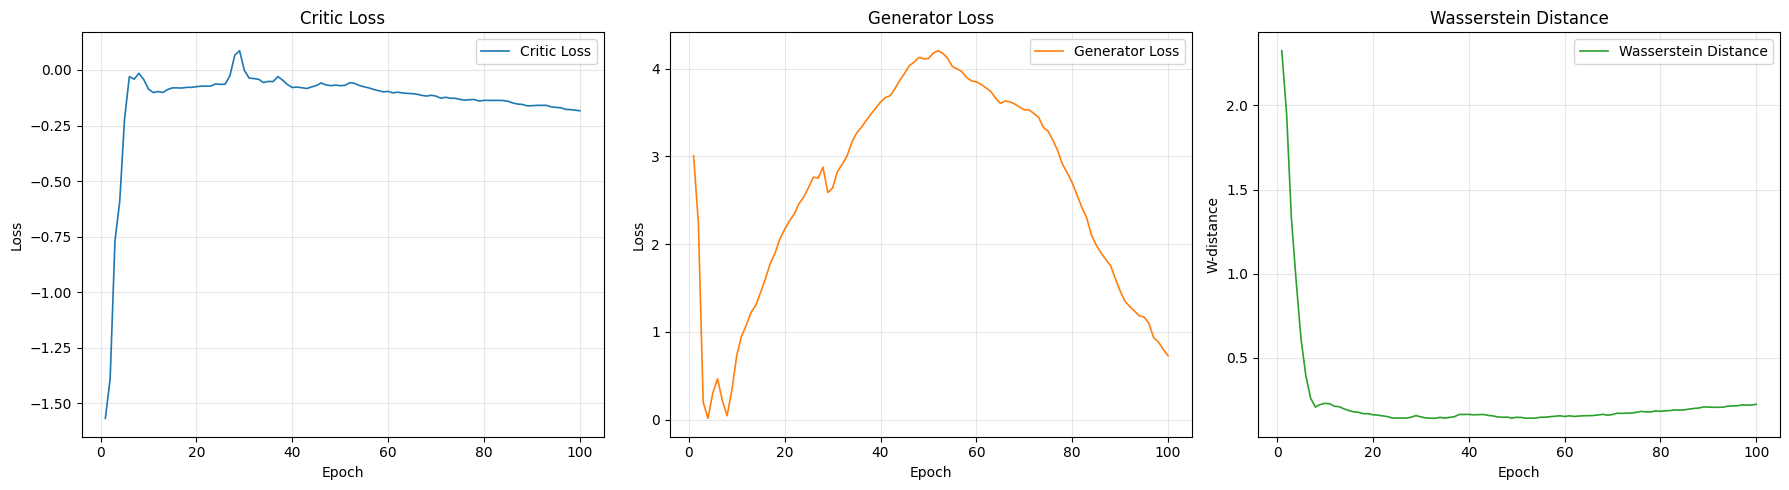

Saved → loss_curves.png


In [20]:
# ── 5a. Loss Curves ──────────────────────────────────────────────────────────
epochs = np.arange(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs, hist["d_loss"], label="Critic Loss", linewidth=1.2)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Critic Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, hist["g_loss"], label="Generator Loss", color="tab:orange", linewidth=1.2)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Generator Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs, hist["w_dist"], label="Wasserstein Distance", color="tab:green", linewidth=1.2)
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("W-distance")
axes[2].set_title("Wasserstein Distance")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → loss_curves.png")

Test-set RMSE (log SA): 1.0659
Test-set MAE  (log SA): 0.7902


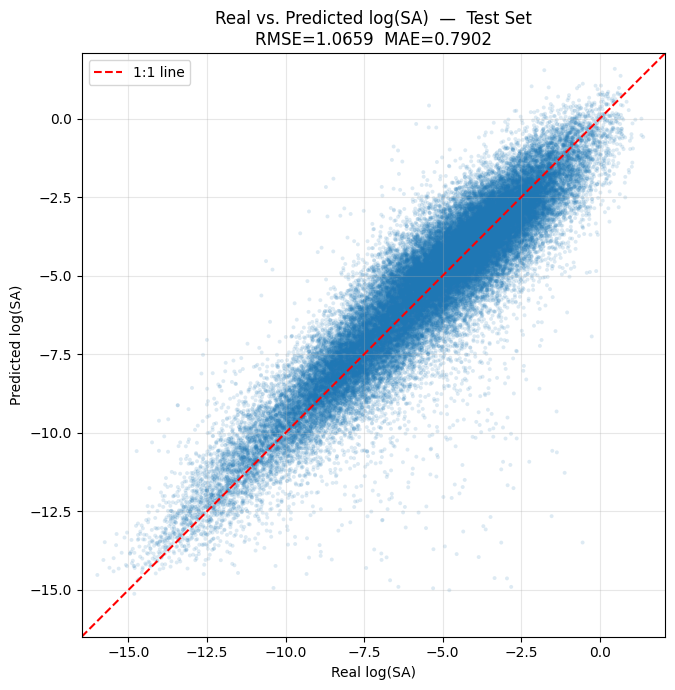

Saved → real_vs_pred.png


In [21]:
# ── 5b. Test-Set Evaluation: Real vs. Predicted log(SA) + RMSE / MAE ─────────
from sklearn.metrics import mean_squared_error, mean_absolute_error

G.eval()

# Generate predictions for the ENTIRE test set
meta_test  = test_dataset.meta.to(device)
per_test   = test_dataset.period.to(device)
real_test  = test_dataset.sa.cpu().numpy().flatten()
period_raw_test = test_dataset.period_raw.cpu().numpy().flatten()   # unscaled Period

with torch.no_grad():
    z_test = torch.randn(len(test_dataset), NOISE_DIM, device=device)
    pred_test = G(z_test, meta_test, per_test).cpu().numpy().flatten()

# ── Regression metrics ──
rmse = np.sqrt(mean_squared_error(real_test, pred_test))
mae  = mean_absolute_error(real_test, pred_test)
print(f"Test-set RMSE (log SA): {rmse:.4f}")
print(f"Test-set MAE  (log SA): {mae:.4f}")

# ── Scatter plot ──
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(real_test, pred_test, alpha=0.15, s=8, edgecolors="none")
lims = [min(real_test.min(), pred_test.min()) - 0.5,
        max(real_test.max(), pred_test.max()) + 0.5]
ax.plot(lims, lims, "r--", linewidth=1.5, label="1:1 line")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Real log(SA)")
ax.set_ylabel("Predicted log(SA)")
ax.set_title(f"Real vs. Predicted log(SA)  —  Test Set\nRMSE={rmse:.4f}  MAE={mae:.4f}")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("real_vs_pred.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → real_vs_pred.png")

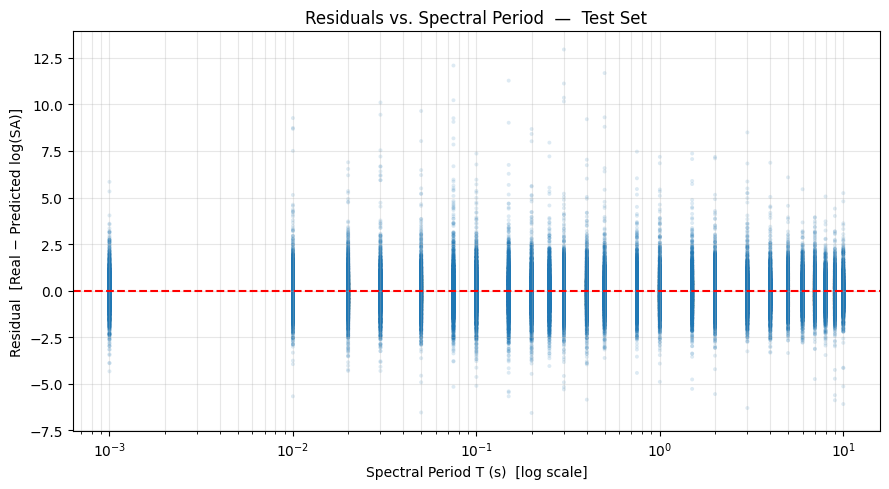

Residual stats → mean: -0.0428,  std: 1.0651
Saved → residuals_vs_period.png


In [22]:
# ── 5c. Residuals vs. Spectral Period ────────────────────────────────────────
residuals = real_test - pred_test

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(period_raw_test, residuals, alpha=0.15, s=8, edgecolors="none")
ax.axhline(0, color="r", linestyle="--", linewidth=1.5)
ax.set_xscale("log")
ax.set_xlabel("Spectral Period T (s)  [log scale]")
ax.set_ylabel("Residual  [Real − Predicted log(SA)]")
ax.set_title("Residuals vs. Spectral Period  —  Test Set")
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("residuals_vs_period.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Residual stats → mean: {residuals.mean():.4f},  std: {residuals.std():.4f}")
print("Saved → residuals_vs_period.png")

Unique earthquake events in test set: 10007


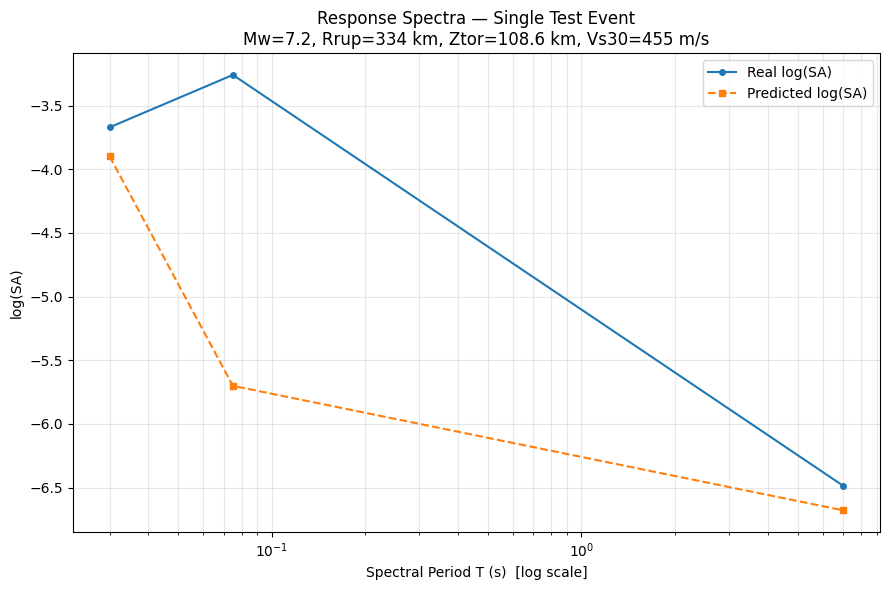

Saved → response_spectra_event.png


In [23]:
# ── 5d. Response Spectra — Single Earthquake Event from Test Set ─────────────
# Pick one random earthquake event (unique Mw, Rrup, Ztor, Vs30 combination)
# and compare Real vs. Predicted log(SA) across all spectral periods.

# Reconstruct test metadata in original (unscaled) space for grouping.
# The scaled columns in df_test are: Mw, log_Rrup, Ztor, log_Vs30, log_Period.
# We use the raw Mw, Rrup, Ztor, Vs30 from df_test (they were scaled, but
# identical rows still share the same scaled values).

event_keys = ["Mw", "log_Rrup", "Ztor", "log_Vs30"]
events = df_test.groupby(event_keys).ngroups
print(f"Unique earthquake events in test set: {events}")

# Randomly select one event
event_groups = df_test.groupby(event_keys)
event_name = list(event_groups.groups.keys())[np.random.randint(events)]
event_df = event_groups.get_group(event_name).sort_values("Period")

# Get the rows' indices into test_dataset
event_idx = event_df.index.values

# Retrieve tensors for this event
meta_ev  = test_dataset.meta[event_idx].to(device)
per_ev   = test_dataset.period[event_idx].to(device)
real_ev  = test_dataset.sa[event_idx].cpu().numpy().flatten()
period_ev = test_dataset.period_raw[event_idx].cpu().numpy().flatten()

with torch.no_grad():
    z_ev = torch.randn(len(event_idx), NOISE_DIM, device=device)
    pred_ev = G(z_ev, meta_ev, per_ev).cpu().numpy().flatten()

# Sort by period for clean line plots
sort_idx = np.argsort(period_ev)
period_ev = period_ev[sort_idx]
real_ev   = real_ev[sort_idx]
pred_ev   = pred_ev[sort_idx]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(period_ev, real_ev,  "o-", label="Real log(SA)",      markersize=4, linewidth=1.5)
ax.plot(period_ev, pred_ev, "s--", label="Predicted log(SA)", markersize=4, linewidth=1.5)
ax.set_xscale("log")
ax.set_xlabel("Spectral Period T (s)  [log scale]")
ax.set_ylabel("log(SA)")

# Inverse-scale the event metadata for the title
cond_scaled = np.zeros((1, 5))
cond_scaled[0, 0] = event_name[0]   # Mw (scaled)
cond_scaled[0, 1] = event_name[1]   # log_Rrup (scaled)
cond_scaled[0, 2] = event_name[2]   # Ztor (scaled)
cond_scaled[0, 3] = event_name[3]   # log_Vs30 (scaled)
cond_scaled[0, 4] = 0.0             # dummy log_Period
cond_orig = scaler.inverse_transform(cond_scaled)[0]
mw_orig   = cond_orig[0]
rrup_orig = np.exp(cond_orig[1])
ztor_orig = cond_orig[2]
vs30_orig = np.exp(cond_orig[3])

ax.set_title(
    f"Response Spectra — Single Test Event\n"
    f"Mw={mw_orig:.1f}, Rrup={rrup_orig:.0f} km, Ztor={ztor_orig:.1f} km, "
    f"Vs30={vs30_orig:.0f} m/s"
)
ax.legend()
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.savefig("response_spectra_event.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → response_spectra_event.png")

## 6 · Save Model Weights

In [24]:
torch.save(G.state_dict(), "global_G.pth")
torch.save(D.state_dict(), "global_D.pth")

print("Saved → global_G.pth")
print("Saved → global_D.pth")
print("Saved → condition_scaler.pkl  (from §1f)")
print("\nPhase 1 complete. These artefacts are ready for Phase 2.")

Saved → global_G.pth
Saved → global_D.pth
Saved → condition_scaler.pkl  (from §1f)

Phase 1 complete. These artefacts are ready for Phase 2.
